In [2]:
pip install shap

Note: you may need to restart the kernel to use updated packages.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, f1_score, roc_curve, roc_auc_score, ConfusionMatrixDisplay
import shap
import warnings
warnings.filterwarnings('ignore')

sns.set(style="whitegrid")

print("Imports done")

Imports done


In [8]:
import zipfile
import os

with zipfile.ZipFile("bank-additional.zip", "r") as z:
    z.extractall("bank-additional-extracted")

print(os.listdir("bank-additional-extracted"))

['bank-additional', '__MACOSX']


In [9]:
print(os.listdir("bank-additional-extracted/bank-additional"))

['.DS_Store', '.Rhistory', 'bank-additional-full.csv', 'bank-additional-names.txt', 'bank-additional.csv']


In [10]:
df = pd.read_csv("bank-additional-extracted/bank-additional/bank-additional-full.csv", sep=';')
print(df.shape)
df.head()

(41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [11]:
df.info()
df.describe()
print(df['y'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

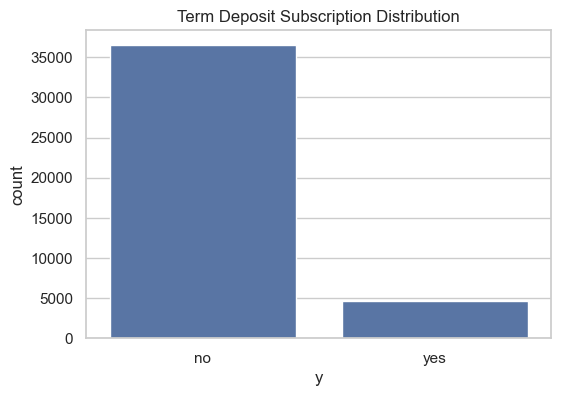

In [12]:
plt.figure(figsize=(6,4))
sns.countplot(x='y', data=df)
plt.title("Term Deposit Subscription Distribution")
plt.show()

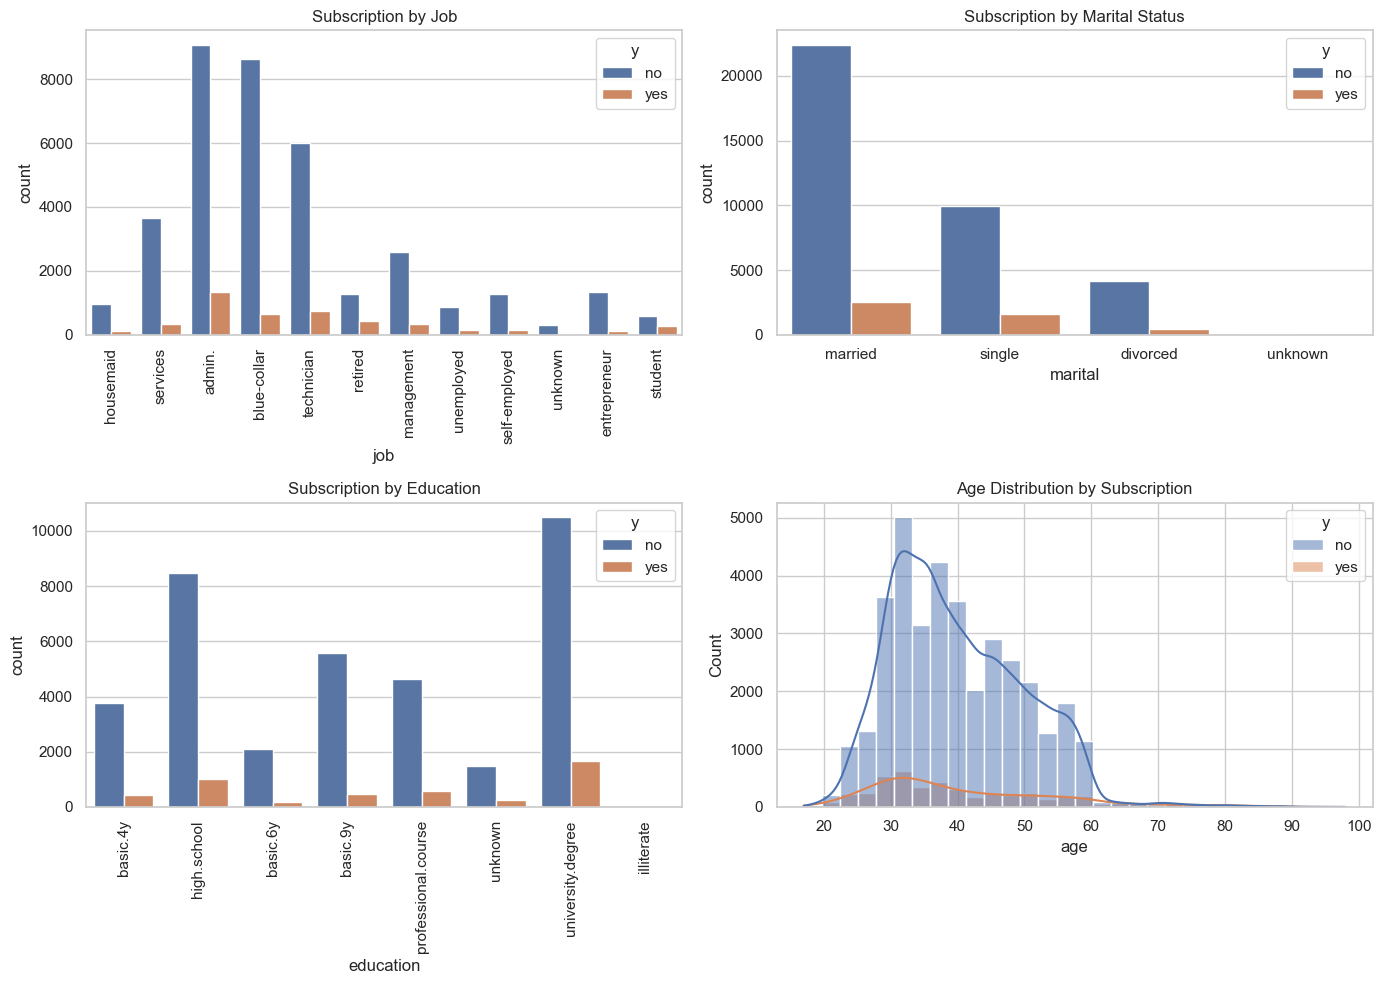

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14,10))

sns.countplot(x='job', hue='y', data=df, ax=axes[0,0])
axes[0,0].tick_params(axis='x', rotation=90)
axes[0,0].set_title("Subscription by Job")

sns.countplot(x='marital', hue='y', data=df, ax=axes[0,1])
axes[0,1].set_title("Subscription by Marital Status")

sns.countplot(x='education', hue='y', data=df, ax=axes[1,0])
axes[1,0].tick_params(axis='x', rotation=90)
axes[1,0].set_title("Subscription by Education")

sns.histplot(data=df, x='age', hue='y', bins=30, kde=True, ax=axes[1,1])
axes[1,1].set_title("Age Distribution by Subscription")

plt.tight_layout()
plt.show()

In [14]:
df_model = df.copy()

df_model['y'] = df_model['y'].map({'yes': 1, 'no': 0})

cat_cols = df_model.select_dtypes(include='object').columns.tolist()
print("Categorical columns:", cat_cols)

encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    encoders[col] = le

df_model.head()

Categorical columns: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,3,1,0,0,0,0,1,6,1,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
1,57,7,1,3,1,0,0,1,6,1,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
2,37,7,1,3,0,2,0,1,6,1,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
3,40,0,1,1,0,0,0,1,6,1,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
4,56,7,1,3,0,0,2,1,6,1,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0


In [15]:
X = df_model.drop('y', axis=1)
y = df_model['y']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)

(32950, 20) (8238, 20)


In [16]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
log_reg.fit(X_train_scaled, y_train)

y_pred_lr = log_reg.predict(X_test_scaled)
y_proba_lr = log_reg.predict_proba(X_test_scaled)[:,1]

print("Logistic Regression Results")
print(classification_report(y_test, y_pred_lr))
print("F1 Score:", f1_score(y_test, y_pred_lr))

Logistic Regression Results
              precision    recall  f1-score   support

           0       0.99      0.85      0.91      7310
           1       0.43      0.90      0.59       928

    accuracy                           0.86      8238
   macro avg       0.71      0.88      0.75      8238
weighted avg       0.92      0.86      0.88      8238

F1 Score: 0.5861705861705861


In [18]:
rf = RandomForestClassifier(n_estimators=200, max_depth=10,
                             class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:,1]

print("Random Forest Results")
print(classification_report(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))

Random Forest Results
              precision    recall  f1-score   support

           0       0.99      0.87      0.93      7310
           1       0.47      0.92      0.63       928

    accuracy                           0.88      8238
   macro avg       0.73      0.90      0.78      8238
weighted avg       0.93      0.88      0.89      8238

F1 Score: 0.6255924170616114


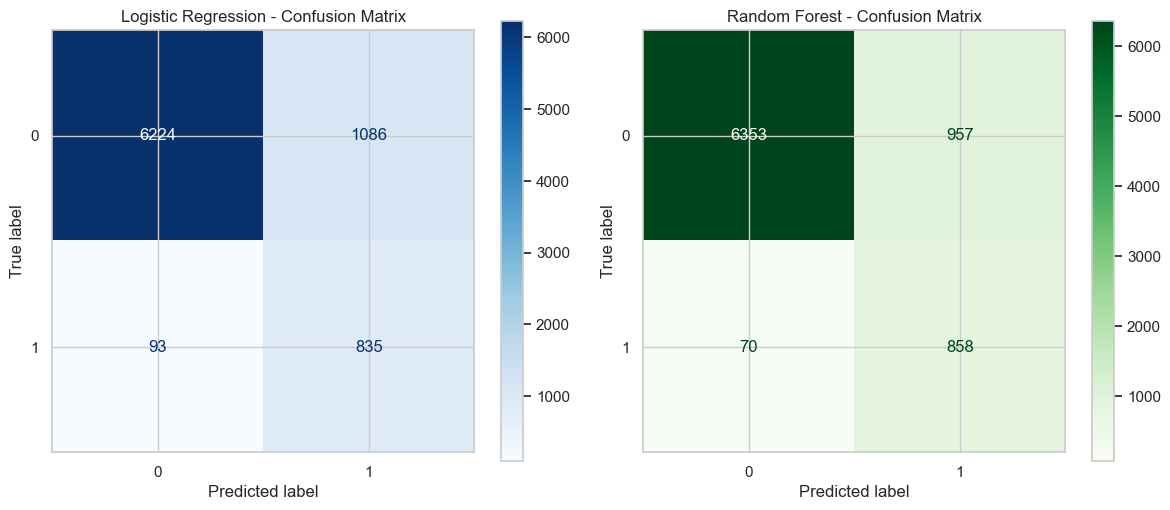

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr, ax=axes[0], cmap='Blues')
axes[0].set_title("Logistic Regression - Confusion Matrix")

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, ax=axes[1], cmap='Greens')
axes[1].set_title("Random Forest - Confusion Matrix")

plt.tight_layout()
plt.show()

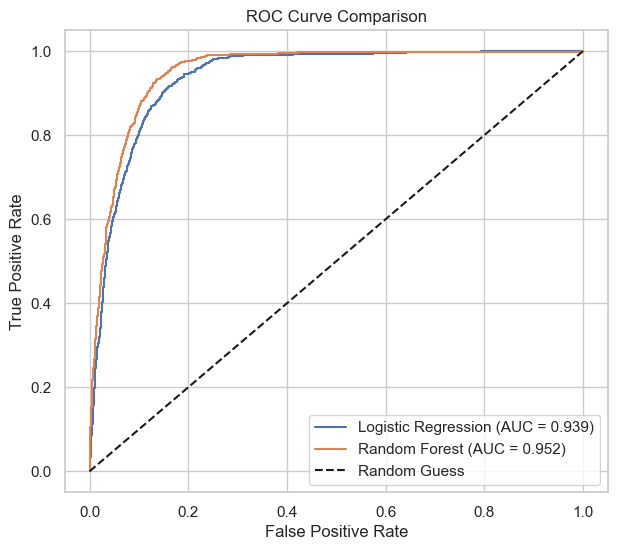

In [20]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)

auc_lr = roc_auc_score(y_test, y_proba_lr)
auc_rf = roc_auc_score(y_test, y_proba_rf)

plt.figure(figsize=(7,6))
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {auc_lr:.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.3f})")
plt.plot([0,1],[0,1],'k--', label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

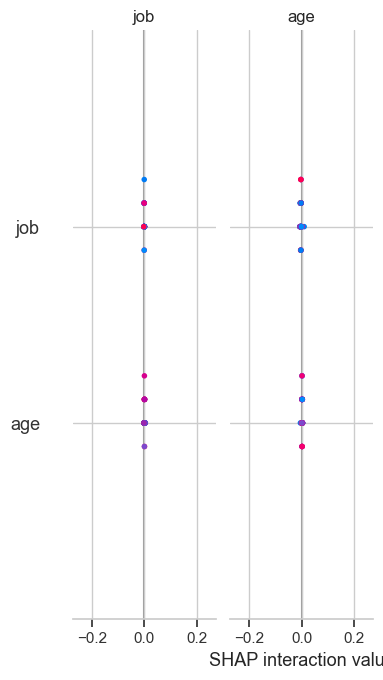

In [26]:
from sklearn.ensemble import RandomForestClassifier

rf_light = RandomForestClassifier(n_estimators=50, max_depth=5,
                                   class_weight='balanced', random_state=42, n_jobs=-1)
rf_light.fit(X_train, y_train)

X_test_sample = X_test.sample(50, random_state=42)

explainer = shap.TreeExplainer(rf_light)
shap_values = explainer.shap_values(X_test_sample, check_additivity=False)

shap_values_class1 = shap_values[1] if isinstance(shap_values, list) else shap_values

shap.summary_plot(shap_values_class1, X_test_sample, plot_type="bar", show=True)

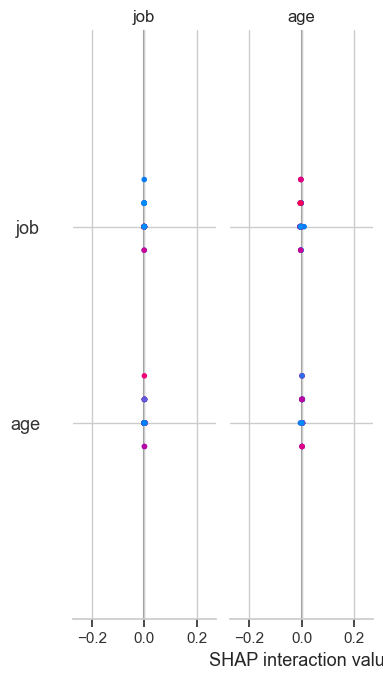

In [27]:
shap.summary_plot(shap_values_class1, X_test_sample, show=True)

In [30]:
print(type(shap_values))
print(np.array(shap_values).shape if not isinstance(shap_values, list) else [s.shape for s in shap_values])

<class 'numpy.ndarray'>
(50, 20, 2)


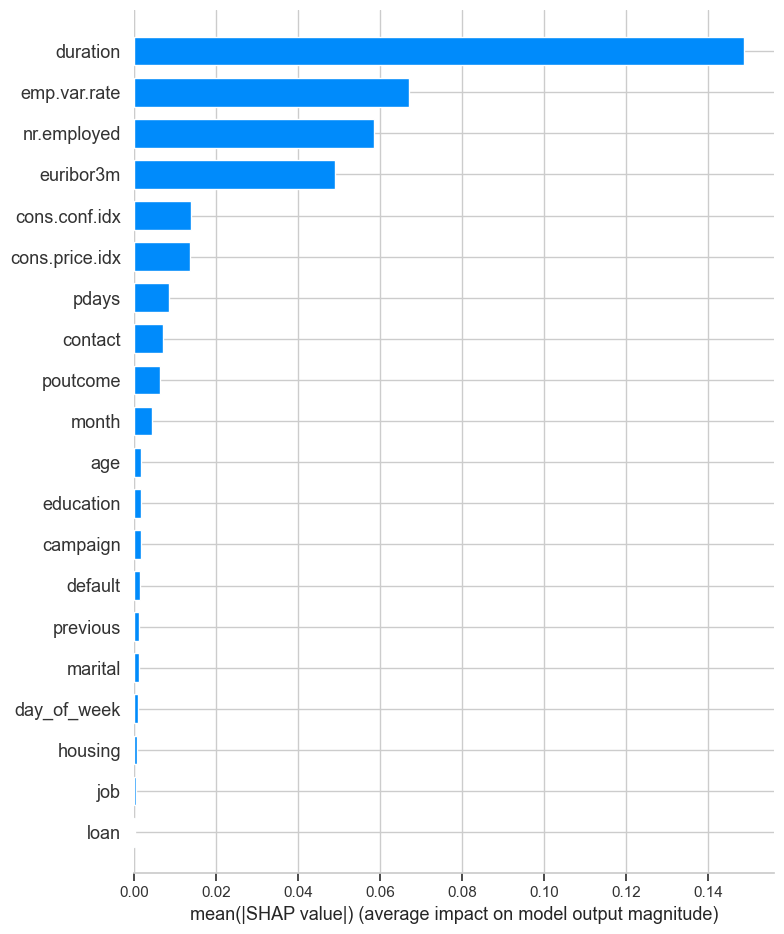

In [31]:
shap_values_class1 = shap_values[:, :, 1] 

shap.summary_plot(shap_values_class1, X_test_sample, plot_type="bar", show=True)

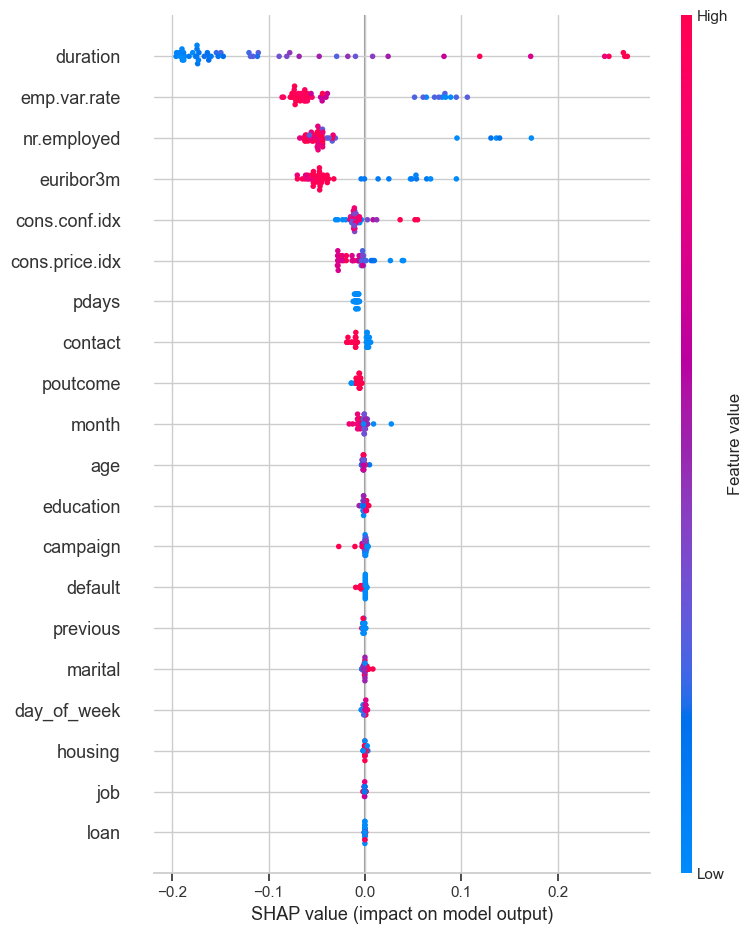

In [32]:
shap.summary_plot(shap_values_class1, X_test_sample, show=True)


--- Explanation for Sample 1 (index 11282) ---
Actual: 0 | Predicted: 1


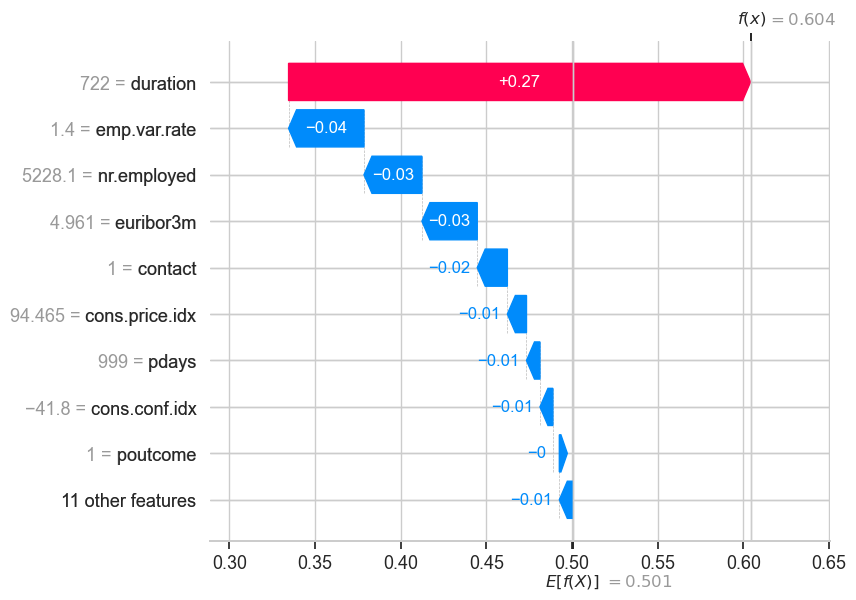


--- Explanation for Sample 2 (index 7450) ---
Actual: 0 | Predicted: 0


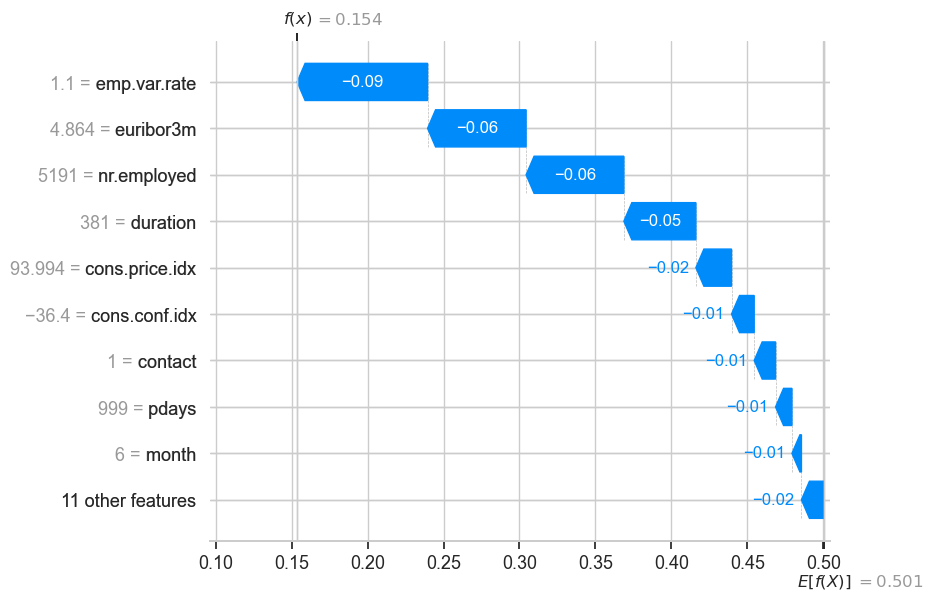


--- Explanation for Sample 3 (index 1190) ---
Actual: 0 | Predicted: 0


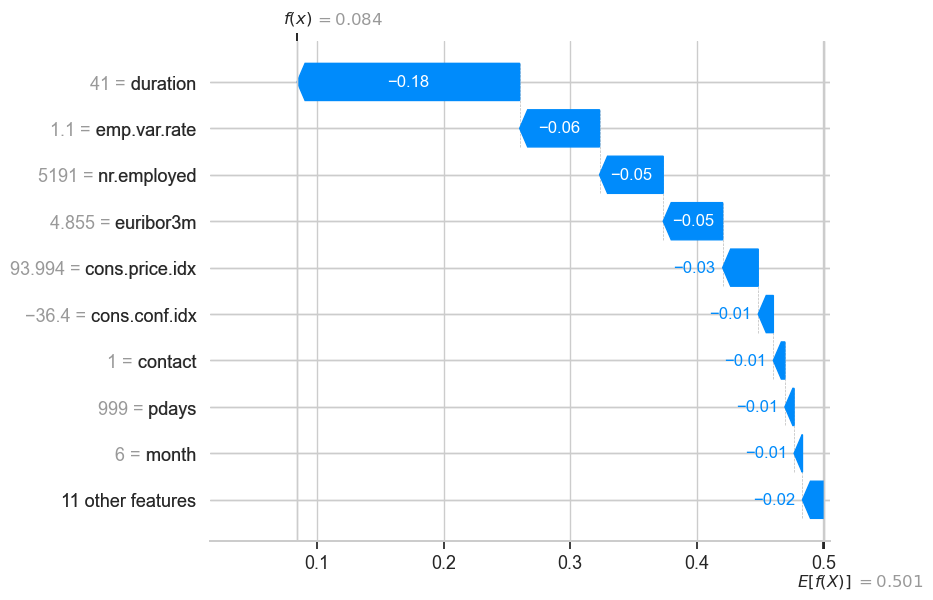


--- Explanation for Sample 4 (index 16329) ---
Actual: 0 | Predicted: 0


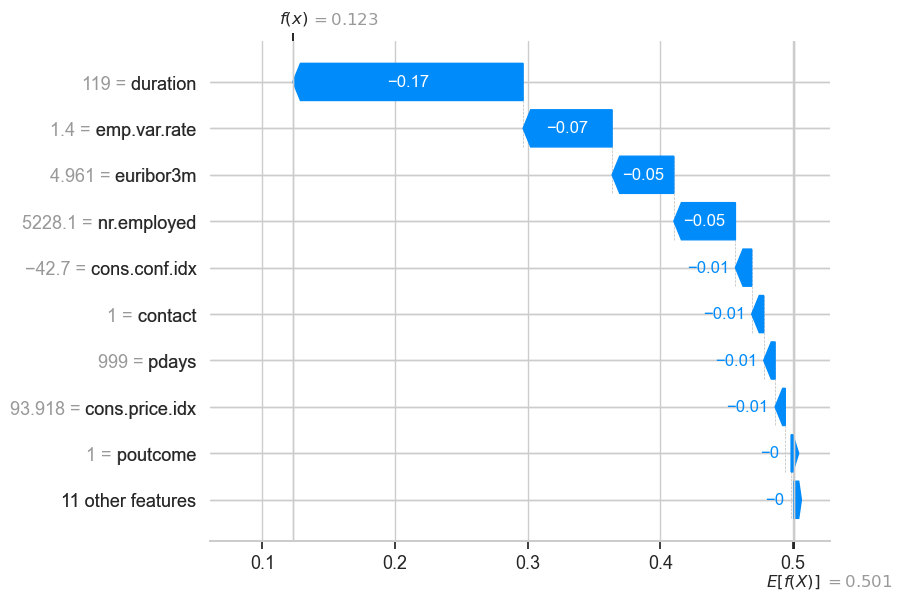


--- Explanation for Sample 5 (index 11825) ---
Actual: 0 | Predicted: 0


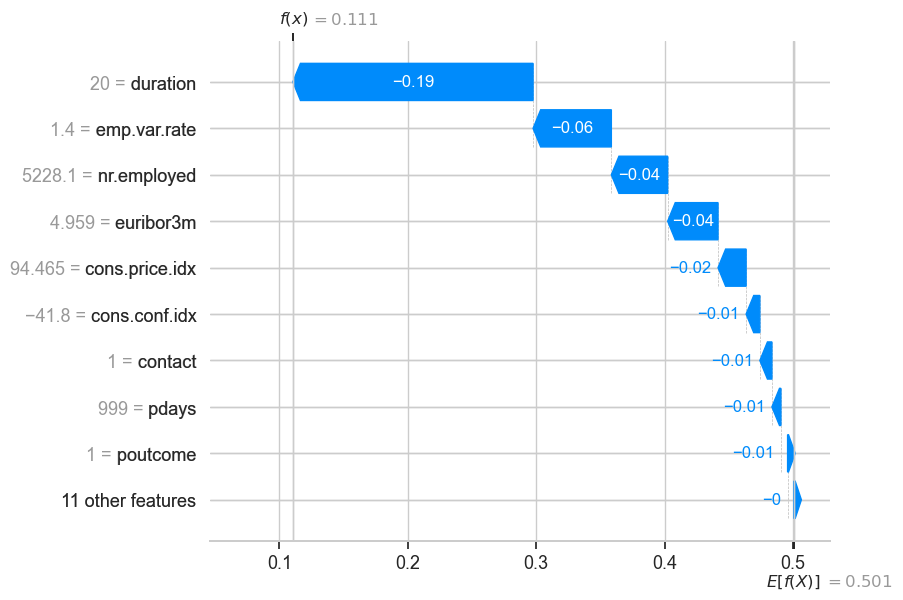

In [33]:
sample_indices = X_test_sample.sample(5, random_state=1).index

for i, idx in enumerate(sample_indices):
    row_pos = X_test_sample.index.get_loc(idx)
    print(f"\n--- Explanation for Sample {i+1} (index {idx}) ---")
    print("Actual:", y_test.loc[idx], "| Predicted:", rf_light.predict(X_test_sample.loc[[idx]])[0])

    base_value = explainer.expected_value[1] if isinstance(explainer.expected_value, np.ndarray) else explainer.expected_value

    shap_explanation = shap.Explanation(
        values=shap_values_class1[row_pos],
        base_values=base_value,
        data=X_test_sample.iloc[row_pos].values,
        feature_names=X_test_sample.columns.tolist()
    )

    shap.plots.waterfall(shap_explanation, show=True)